# Physical Activity — Multi-Algorithm Clustering: Best Model Selection

**Pipeline:** Load & Inspect → TF-IDF Feature Engineering → TruncatedSVD + L2-norm → Algorithm Race (6 algorithms × 10 K-values) → Automated Winner Selection → Final Model → Profile & Name Clusters → Heatmap → 2D/3D Visualisation → Export

**Why this approach?**  
The dataset contains only two meaningful columns: `Actvitiy` (22 category labels) and `Description` (free text, ~1121 unique phrases). There are no numeric features. The correct strategy is therefore **text clustering** using TF-IDF → TruncatedSVD (Latent Semantic Analysis) → L2-normalised cosine space → cluster with multiple algorithms and let the metrics decide the winner automatically.

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.cluster import (
    KMeans, AgglomerativeClustering,
    MiniBatchKMeans, BisectingKMeans, DBSCAN
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors
import plotly.express as px

RANDOM_STATE = 42
K_MIN, K_MAX = 3, 22     # Extended: K=2 excluded, K=22 = number of activity categories
SAMPLE_SIZE  = 1000      # for slow metrics
N_SVD        = 50        # TruncatedSVD components

np.random.seed(RANDOM_STATE)
print('All imports OK')
print(f'K search range: {K_MIN} to {K_MAX}')


All imports OK
K search range: 3 to 22


In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('physical_activity.csv')

# 1. Count the number of columns
num_columns = len(df.columns)
print(f"Total number of columns: {num_columns}")
print(f"Column Names: {df.columns.tolist()}")

# 2. Get unique values for each column
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"\nColumn: '{col}'")
    print(f"Count of unique values: {unique_count}")
    
    # If there are a manageable number of unique values, print them all
    if unique_count <= 25:
        print(f"Unique values: {df[col].unique().tolist()}")
    else:
        # Otherwise, just show the first 5 samples
        print(f"First 5 unique values: {df[col].unique().tolist()[:5]}")

Total number of columns: 2
Column Names: ['Actvitiy', 'Description']

Column: 'Actvitiy'
Count of unique values: 22
Unique values: ['Bicycling', 'Conditioning Exercise', 'Dancing', 'Fishing & Hunting', 'Home Activities', 'Home Repair', 'Inactivity', 'Lawn & Garden', 'Miscellaneous', 'Music Playing', 'Occupation', 'Running', 'Self Care', 'Sexual Activity', 'Sports', 'Transportation', 'Walking', 'Water Activities', 'Winter Activities', 'Religious Activities', 'Volunteer Activities', 'Video Games']

Column: 'Description'
Count of unique values: 1121
First 5 unique values: ['Bicycling, mountain, competitive racing', 'Bicycling, BMX', 'Bicycling, mountain, general', 'Bicycling, <10 mph, leisure, to work or for pleasure (Taylor Code 115)', 'Bicycling, to/from work, self selected pace']


## 1. Load & Inspect

In [2]:
df_raw = pd.read_csv('physical_activity.csv')

print('=== Shape ===')
print(df_raw.shape)

print('\n=== Columns and dtypes ===')
print(df_raw.dtypes)

print('\n=== Missing values ===')
print(df_raw.isnull().sum())

print('\n=== Activity distribution (22 categories) ===')
print(df_raw['Actvitiy'].value_counts())

print(f'\nTotal unique descriptions: {df_raw["Description"].nunique()}')

print('\n=== Sample rows ===')
for _, row in df_raw.head(6).iterrows():
    print(f'  [{row["Actvitiy"]:25s}] {row["Description"][:70]}')

=== Shape ===
(1125, 3)

=== Columns and dtypes ===
Unnamed: 0      int64
Actvitiy       object
Description    object
dtype: object

=== Missing values ===
Unnamed: 0     0
Actvitiy       0
Description    0
dtype: int64

=== Activity distribution (22 categories) ===
Actvitiy
Sports                   157
Occupation               156
Walking                   93
Water Activities          87
Conditioning Exercise     87
Home Activities           81
Running                   66
Lawn & Garden             55
Winter Activities         52
Bicycling                 43
Home Repair               37
Fishing & Hunting         37
Dancing                   30
Miscellaneous             28
Religious Activities      24
Music Playing             22
Volunteer Activities      19
Inactivity                17
Transportation            12
Self Care                 11
Video Games                8
Sexual Activity            3
Name: count, dtype: int64

Total unique descriptions: 1121

=== Sample rows ===
  [Bic

## 2. Feature Engineering

**Why TF-IDF + TruncatedSVD (LSA)?**
- The dataset has **no numeric features** — only text. TF-IDF converts text to a numeric feature matrix.
- `ngram_range=(1,2)` captures single words and 2-word phrases (e.g. `weight lifting`, `water cycling`).
- `sublinear_tf=True` applies `log(1+tf)` — dampens very frequent words.
- `TruncatedSVD` (LSA) is preferred over PCA for sparse TF-IDF matrices — works on sparse format directly.
- **L2-normalisation** preserves cosine similarity in reduced space — essential for text clustering.
- Activity name is prepended to description so TF-IDF captures both the category and the specific activity vocabulary together.

In [3]:
df = df_raw.copy()
df.drop(columns=['Unnamed: 0'], inplace=True)

# Concatenate Activity + Description into one rich text field
df['full_text'] = (
    df['Actvitiy'].str.lower().str.replace('&', 'and')
    + ' '
    + df['Description'].str.lower().fillna('')
)
print('Sample full_text:')
for t in df['full_text'].iloc[:3]:
    print(f'  "{t[:88]}"')

# TF-IDF
tfidf = TfidfVectorizer(
    stop_words   = 'english',
    max_features = 1000,
    ngram_range  = (1, 2),
    min_df       = 2,
    sublinear_tf = True
)
X_tfidf = tfidf.fit_transform(df['full_text'])
print(f'\nTF-IDF matrix : {X_tfidf.shape}  '
      f'(sparsity {1 - X_tfidf.nnz/np.prod(X_tfidf.shape):.3f})')

# TruncatedSVD (LSA)
svd    = TruncatedSVD(n_components=N_SVD, random_state=RANDOM_STATE)
X_svd  = svd.fit_transform(X_tfidf)
cumvar = np.cumsum(svd.explained_variance_ratio_)

print(f'\nSVD cumulative variance:')
for cp in [9, 19, 29, 39, 49]:
    print(f'  {cp+1:3d} components: {cumvar[cp]:.3f}')

# ── 90% variance rule — CRITICAL FIX ─────────────────────────────────────────
# np.argmax([False, False, ...]) returns 0, not 'not found'.
# If 90% is never reached, argmax returns 0 → we'd truncate to 1 component → disaster.
# Correct approach: check .any() first; if not reached, keep ALL components.
if not (cumvar >= 0.90).any():
    print(f'\n90% variance NOT reached within {N_SVD} components (max cumvar={cumvar[-1]:.3f})')
    print(f'→ Keeping ALL {N_SVD} SVD components. This is expected for text data.')
    X_reduced = X_svd
else:
    n_for_90 = int(np.argmax(cumvar >= 0.90)) + 1
    print(f'\n90% variance reached at {n_for_90} components → truncating')
    X_reduced = X_svd[:, :n_for_90]

# L2 normalise — preserves cosine structure for text clustering
X_final = normalize(X_reduced, norm='l2')
print(f'\nX_final shape : {X_final.shape}  ← must be (1125, 50)')
print(f'Row L2-norm (should be 1.0): {np.linalg.norm(X_final[0]):.6f}')


Sample full_text:
  "bicycling bicycling, mountain, competitive racing"
  "bicycling bicycling, bmx"
  "bicycling bicycling, mountain, general"

TF-IDF matrix : (1125, 1000)  (sparsity 0.992)

SVD cumulative variance:
   10 components: 0.191
   20 components: 0.298
   30 components: 0.365
   40 components: 0.418
   50 components: 0.459

90% variance NOT reached within 50 components (max cumvar=0.459)
→ Keeping ALL 50 SVD components. This is expected for text data.

X_final shape : (1125, 50)  ← must be (1125, 50)
Row L2-norm (should be 1.0): 1.000000


## 3. SVD Variance Plot

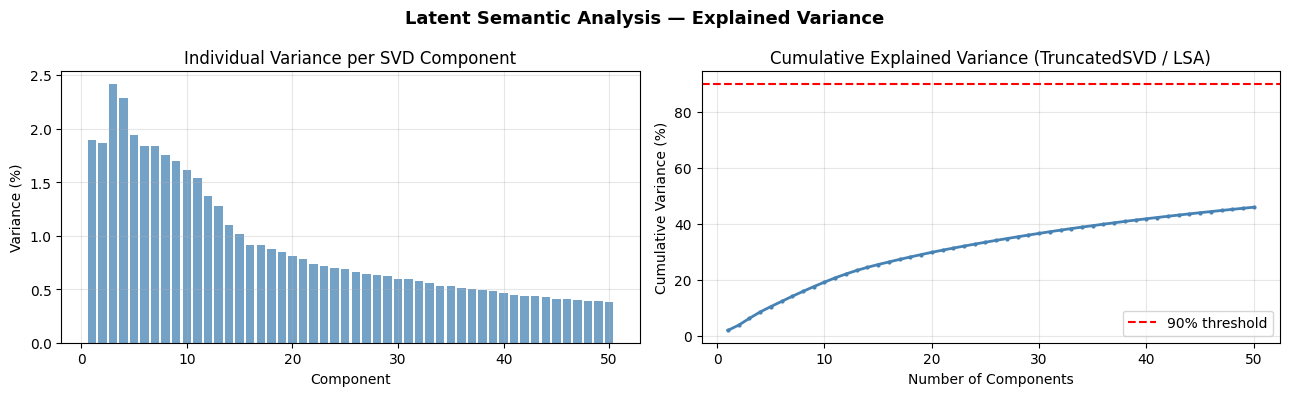

Saved: svd_variance.png


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(range(1, N_SVD+1), svd.explained_variance_ratio_*100, color='steelblue', alpha=0.75)
ax1.set_title('Individual Variance per SVD Component')
ax1.set_xlabel('Component'); ax1.set_ylabel('Variance (%)')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, N_SVD+1), cumvar*100, marker='.', color='steelblue', lw=2, ms=4)
ax2.axhline(90, color='red', linestyle='--', lw=1.5, label='90% threshold')
ax2.set_title('Cumulative Explained Variance (TruncatedSVD / LSA)')
ax2.set_xlabel('Number of Components'); ax2.set_ylabel('Cumulative Variance (%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Latent Semantic Analysis — Explained Variance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('svd_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: svd_variance.png')                                                                     

## 4. Algorithm Race — 5 Algorithms x K = 3 to 12

| Algorithm | Type | Key property |
|---|---|---|
| **KMeans** | Centroid | Fast, reliable, assumes spherical clusters |
| **MiniBatchKMeans** | Centroid stochastic | Faster, slightly noisier |
| **BisectingKMeans** | Hierarchical centroid | Recursive bisection, handles uneven sizes |
| **AgglomerativeClustering (Ward)** | Hierarchical | Minimises within-cluster variance |
| **GaussianMixture (GMM)** | Probabilistic | Soft assignments, handles elliptical clusters |

Metrics: Silhouette (higher better), Davies-Bouldin (lower better), Calinski-Harabasz (higher better). All computed on 1000-point sample; models fit on full data.

In [5]:
rng      = np.random.RandomState(RANDOM_STATE)
n_samp   = min(SAMPLE_SIZE, len(X_final))
idx_samp = rng.choice(len(X_final), size=n_samp, replace=False)

race_rows   = []
race_labels = {}

K_RANGE = range(K_MIN, K_MAX + 1)

print(f'Algorithm race: K={K_MIN}-{K_MAX}, sample={n_samp}')
print('=' * 78, flush=True)

for k in K_RANGE:
    algos_k = [
        ('KMeans',          KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)),
        ('MiniBatchKMeans', MiniBatchKMeans(n_clusters=k, n_init=10,
                                           random_state=RANDOM_STATE, batch_size=256)),
        ('BisectingKMeans', BisectingKMeans(n_clusters=k, random_state=RANDOM_STATE,
                                            bisecting_strategy='largest_cluster')),
        ('Agglomerative',   AgglomerativeClustering(n_clusters=k, linkage='ward')),
        ('GMM',             GaussianMixture(n_components=k, n_init=3,
                                            random_state=RANDOM_STATE, covariance_type='diag')),
    ]

    for name, algo in algos_k:
        lbl = algo.fit_predict(X_final)

        Xs = X_final[idx_samp]
        Ls = lbl[idx_samp]

        # ✅ FIX: check number of clusters
        n_labels = len(np.unique(Ls))

        if n_labels < 2:
            sil = np.nan
            db  = np.nan
            ch  = np.nan
            print(f'  K={k:2d}  {name:18s}  ⚠️ Only 1 cluster formed → skipping metrics', flush=True)
        else:
            sil = silhouette_score(Xs, Ls, random_state=RANDOM_STATE)
            db  = davies_bouldin_score(Xs, Ls)
            ch  = calinski_harabasz_score(Xs, Ls)

            mnsz = int(pd.Series(lbl).value_counts().min())

            print(f'  K={k:2d}  {name:18s}  Sil={sil:.4f}  DB={db:.4f}  CH={ch:.2f}  min_sz={mnsz}', flush=True)

        # compute min cluster size safely
        mnsz = int(pd.Series(lbl).value_counts().min())

        race_rows.append(dict(
            Algorithm=name,
            K=k,
            Silhouette=sil,
            DaviesBouldin=db,
            CalinskiHarabasz=ch,
            MinClusterSize=mnsz
        ))

        race_labels[(name, k)] = lbl.copy()

    print(flush=True)

race_df = pd.DataFrame(race_rows)
print('Race complete.', flush=True)

Algorithm race: K=3-22, sample=1000
  K= 3  KMeans              Sil=0.0717  DB=2.8788  CH=51.81  min_sz=144
  K= 3  MiniBatchKMeans     Sil=0.0705  DB=3.7678  CH=49.61  min_sz=147
  K= 3  BisectingKMeans     Sil=0.0648  DB=4.0914  CH=41.80  min_sz=209
  K= 3  Agglomerative       Sil=0.0778  DB=1.9641  CH=55.41  min_sz=88
  K= 3  GMM                 Sil=0.0357  DB=5.0635  CH=27.12  min_sz=270

  K= 4  KMeans              Sil=0.1028  DB=3.3615  CH=52.92  min_sz=131
  K= 4  MiniBatchKMeans     Sil=0.0938  DB=3.4333  CH=48.87  min_sz=153
  K= 4  BisectingKMeans     Sil=0.0912  DB=3.4875  CH=47.40  min_sz=192
  K= 4  Agglomerative       Sil=0.0984  DB=1.9414  CH=53.44  min_sz=64
  K= 4  GMM                 Sil=0.0814  DB=3.7577  CH=42.96  min_sz=142

  K= 5  KMeans              Sil=0.1179  DB=3.1023  CH=51.50  min_sz=154
  K= 5  MiniBatchKMeans     Sil=0.1122  DB=3.1613  CH=48.54  min_sz=154
  K= 5  BisectingKMeans     Sil=0.1109  DB=3.0455  CH=47.63  min_sz=192
  K= 5  Agglomerative       

## 5. DBSCAN — Density-Based Benchmark

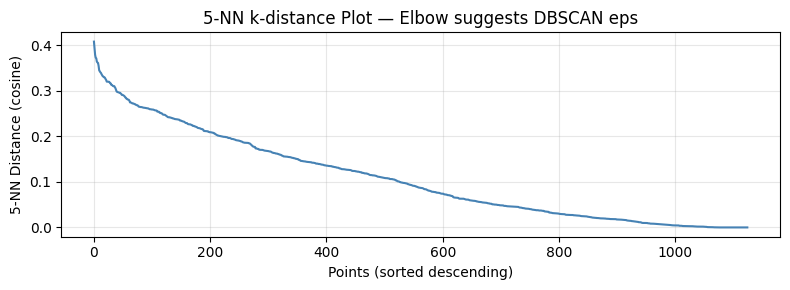

Sweeping DBSCAN (eps x min_samples)...
  eps=0.29  min_s=3  K=15  noise=0.4%  Sil=0.0274
  eps=0.29  min_s=5  K=13  noise=1.3%  Sil=0.0712
  eps=0.31  min_s=3  K=14  noise=0.2%  Sil=0.0317
  eps=0.31  min_s=5  K=12  noise=1.2%  Sil=0.0634
  eps=0.31  min_s=8  K=13  noise=2.2%  Sil=0.1054
  eps=0.31  min_s=10  K=14  noise=5.2%  Sil=0.1746
  eps=0.33  min_s=3  K=10  noise=0.1%  Sil=0.0613
  eps=0.33  min_s=5  K=10  noise=0.3%  Sil=0.0588
  eps=0.33  min_s=8  K=10  noise=0.9%  Sil=0.0470
  eps=0.33  min_s=10  K=10  noise=3.3%  Sil=0.1250
  eps=0.35  min_s=3  K=6  noise=0.0%  Sil=0.0624
  eps=0.35  min_s=5  K=6  noise=0.0%  Sil=0.0624
  eps=0.35  min_s=8  K=6  noise=0.6%  Sil=0.0625
  eps=0.35  min_s=10  K=6  noise=1.3%  Sil=0.0666
  eps=0.37  min_s=3  K=4  noise=0.0%  Sil=0.0342
  eps=0.37  min_s=5  K=4  noise=0.0%  Sil=0.0342
  eps=0.37  min_s=8  K=4  noise=0.1%  Sil=0.0383
  eps=0.37  min_s=10  K=4  noise=1.2%  Sil=0.0394
  eps=0.39  min_s=3  K=3  noise=0.0%  Sil=0.0376
  eps=0.39  min_

In [6]:
# k-distance plot
nbrs     = NearestNeighbors(n_neighbors=5, metric='cosine').fit(X_final)
dists, _ = nbrs.kneighbors(X_final)
k_dists  = np.sort(dists[:, 4])[::-1]

plt.figure(figsize=(8, 3))
plt.plot(k_dists, color='steelblue', lw=1.5)
plt.title('5-NN k-distance Plot — Elbow suggests DBSCAN eps')
plt.xlabel('Points (sorted descending)'); plt.ylabel('5-NN Distance (cosine)')
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()

# Sweep
best_dbscan = None
best_dbscan_labels = None
dbscan_records = []
print('Sweeping DBSCAN (eps x min_samples)...', flush=True)

for eps in np.arange(0.05, 0.55, 0.02):
    for min_s in [3, 5, 8, 10]:
        lbl_db    = DBSCAN(eps=round(eps,2), min_samples=min_s,
                           metric='cosine', n_jobs=-1).fit_predict(X_final)
        n_clust   = len(set(lbl_db)) - (1 if -1 in lbl_db else 0)
        noise_pct = (lbl_db == -1).sum() / len(lbl_db) * 100
        if 3 <= n_clust <= 15 and noise_pct < 20:
            valid = lbl_db != -1
            if valid.sum() > 100:
                sil_db = silhouette_score(
                    X_final[valid], lbl_db[valid],
                    sample_size=min(500, valid.sum()),
                    random_state=RANDOM_STATE)
                rec = dict(eps=round(eps,2), min_samples=min_s,
                           n_clusters=n_clust, noise_pct=round(noise_pct,1),
                           silhouette=round(sil_db,4))
                dbscan_records.append(rec)
                if best_dbscan is None or sil_db > best_dbscan['silhouette']:
                    best_dbscan = rec
                    best_dbscan_labels = lbl_db
                print(f'  eps={eps:.2f}  min_s={min_s}  K={n_clust}  '
                      f'noise={noise_pct:.1f}%  Sil={sil_db:.4f}', flush=True)

if best_dbscan:
    print(f'\nBest DBSCAN: {best_dbscan}')
    # Append best DBSCAN row to race_df for joint comparison
    race_df = pd.concat([race_df, pd.DataFrame([dict(
        Algorithm='DBSCAN', K=best_dbscan['n_clusters'],
        Silhouette=best_dbscan['silhouette'],
        DaviesBouldin=np.nan, CalinskiHarabasz=np.nan,
        MinClusterSize=np.nan)])], ignore_index=True)
else:
    print('No valid DBSCAN config found.')

## 6. Automated Winner Selection

Scoring: normalise Silhouette (up), inverse-DB (down=better), CH (up) each to [0,1] and sum. Penalise min_cluster_size < 15. K=2 excluded from the start.

In [7]:
scored = race_df.dropna(subset=['Silhouette','DaviesBouldin','CalinskiHarabasz']).copy()

def norm01(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-12)

scored['Sil_n']  = norm01(scored['Silhouette'])
scored['DB_n']   = 1 - norm01(scored['DaviesBouldin'])
scored['CH_n']   = norm01(scored['CalinskiHarabasz'])
scored['Penalty'] = np.where(
    scored['MinClusterSize'] < 15,
    (1 - scored['MinClusterSize'] / 15) * 0.4,
    0
)
scored['CombinedScore'] = scored['Sil_n'] + scored['DB_n'] + scored['CH_n'] - scored['Penalty']

top20 = scored.sort_values('CombinedScore', ascending=False).head(20)
print('TOP 20 Algorithm x K combinations:')
print(top20[['Algorithm','K','Silhouette','DaviesBouldin',
             'CalinskiHarabasz','MinClusterSize','CombinedScore']].to_string(index=False))

winner    = scored.sort_values('CombinedScore', ascending=False).iloc[0]
BEST_ALGO = winner['Algorithm']
BEST_K    = int(winner['K'])

print(f'\nWINNER: {BEST_ALGO}  K={BEST_K}')
print(f'  Silhouette        = {winner["Silhouette"]:.4f}')
print(f'  Davies-Bouldin    = {winner["DaviesBouldin"]:.4f}')
print(f'  Calinski-Harabasz = {winner["CalinskiHarabasz"]:.2f}')
print(f'  Min cluster size  = {int(winner["MinClusterSize"])}')
print(f'  Combined score    = {winner["CombinedScore"]:.4f}')

TOP 20 Algorithm x K combinations:
      Algorithm  K  Silhouette  DaviesBouldin  CalinskiHarabasz  MinClusterSize  CombinedScore
         KMeans 17    0.305198       1.687242         62.760027            22.0       2.877854
         KMeans 15    0.295974       1.659967         63.576774            30.0       2.875898
         KMeans 18    0.308574       1.712351         62.148285            22.0       2.865683
  Agglomerative 22    0.322821       1.756046         60.610300            17.0       2.860674
         KMeans 22    0.321142       1.675923         59.744286            18.0       2.853894
  Agglomerative 21    0.318812       1.767092         60.670453            17.0       2.845213
         KMeans 16    0.296347       1.766114         63.368510            22.0       2.841251
         KMeans 21    0.320764       1.552577         59.920926            13.0       2.839222
  Agglomerative 20    0.312611       1.809052         60.584346            17.0       2.809303
            GMM

## 7. Algorithm x K Metric Heatmaps

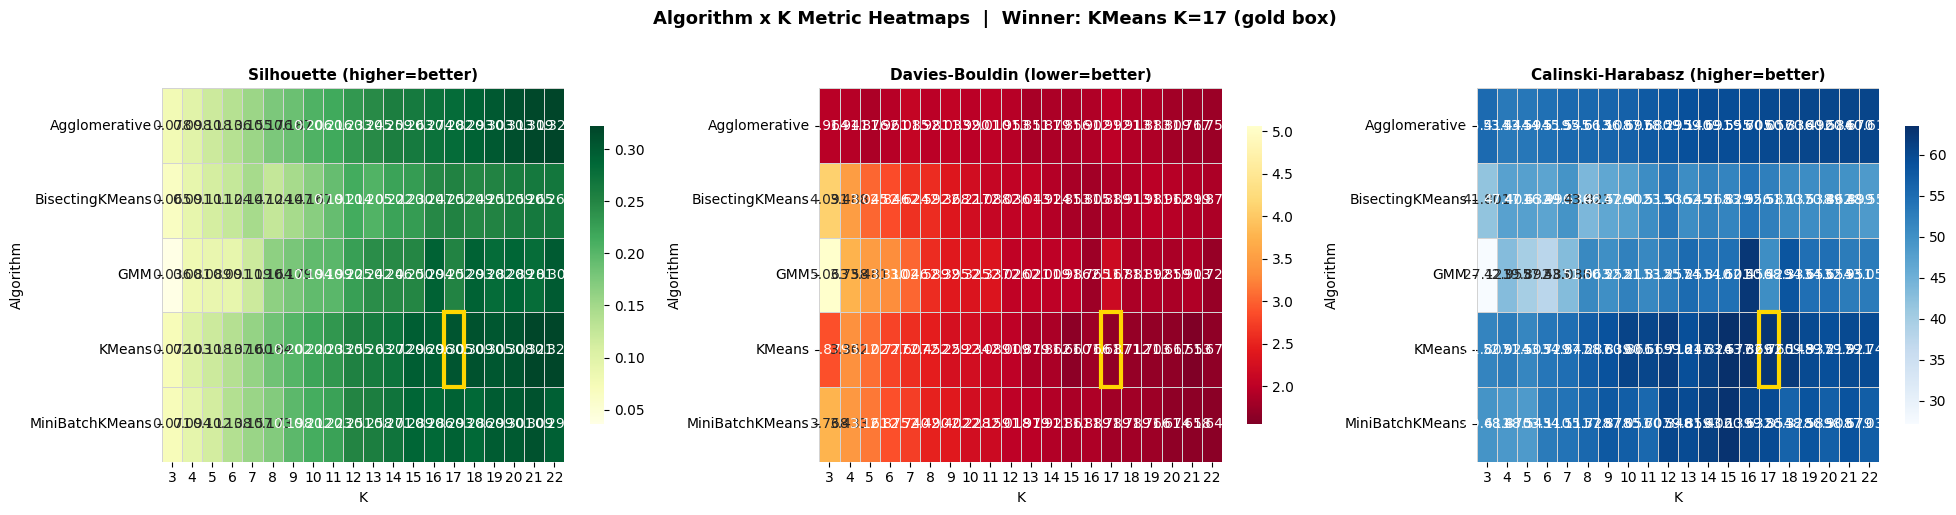

Saved: algo_metric_heatmaps.png


In [8]:
plot_df = scored[scored['Algorithm'] != 'DBSCAN'].copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
metric_cfg = [
    ('Silhouette',       'Silhouette (higher=better)',    'YlGn'),
    ('DaviesBouldin',    'Davies-Bouldin (lower=better)', 'YlOrRd_r'),
    ('CalinskiHarabasz', 'Calinski-Harabasz (higher=better)', 'Blues'),
]
for ax, (col, title, cmap) in zip(axes, metric_cfg):
    piv = plot_df.pivot(index='Algorithm', columns='K', values=col)
    sns.heatmap(piv, ax=ax, cmap=cmap, annot=True, fmt='.3f',
                linewidths=0.4, linecolor='lightgrey', cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('K'); ax.set_ylabel('Algorithm')
    if BEST_ALGO in piv.index and BEST_K in piv.columns:
        ri = list(piv.index).index(BEST_ALGO)
        ci = list(piv.columns).index(BEST_K)
        ax.add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False, edgecolor='gold', lw=3))

plt.suptitle(f'Algorithm x K Metric Heatmaps  |  Winner: {BEST_ALGO} K={BEST_K} (gold box)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('algo_metric_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: algo_metric_heatmaps.png')

## 8. Combined Score Heatmap

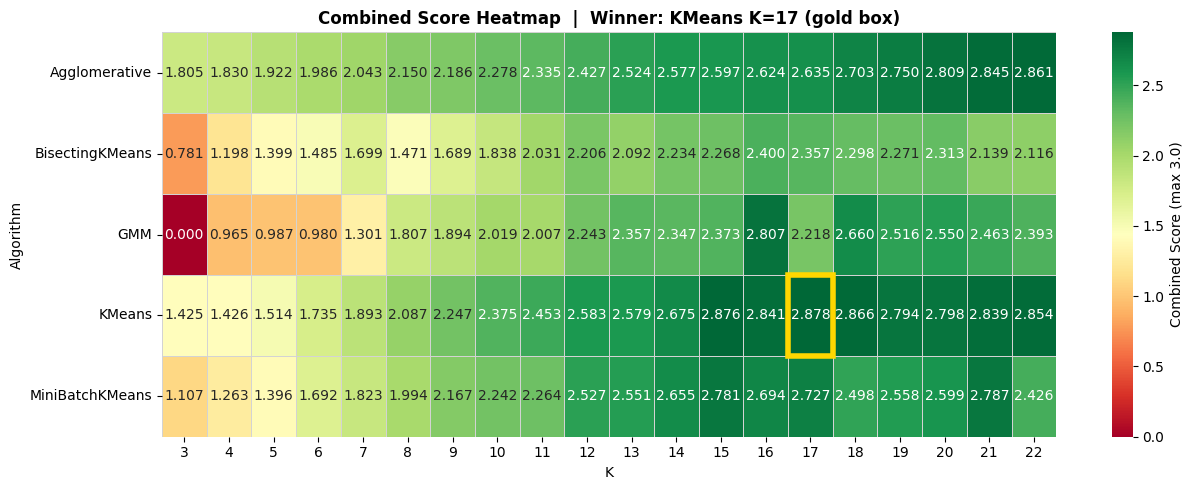

Saved: combined_score_heatmap.png


In [9]:
piv_score = plot_df.pivot(index='Algorithm', columns='K', values='CombinedScore')

plt.figure(figsize=(13, 5))
sns.heatmap(piv_score, cmap='RdYlGn', annot=True, fmt='.3f',
            linewidths=0.4, linecolor='lightgrey',
            cbar_kws={'label': 'Combined Score (max 3.0)'})
if BEST_ALGO in piv_score.index and BEST_K in piv_score.columns:
    ri = list(piv_score.index).index(BEST_ALGO)
    ci = list(piv_score.columns).index(BEST_K)
    plt.gca().add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False, edgecolor='gold', lw=4))
plt.title(f'Combined Score Heatmap  |  Winner: {BEST_ALGO} K={BEST_K} (gold box)',
          fontsize=12, fontweight='bold')
plt.xlabel('K'); plt.ylabel('Algorithm')
plt.tight_layout()
plt.savefig('combined_score_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: combined_score_heatmap.png')

## 9. Winner Algorithm — 4-Metric Curves (2x2 Grid)

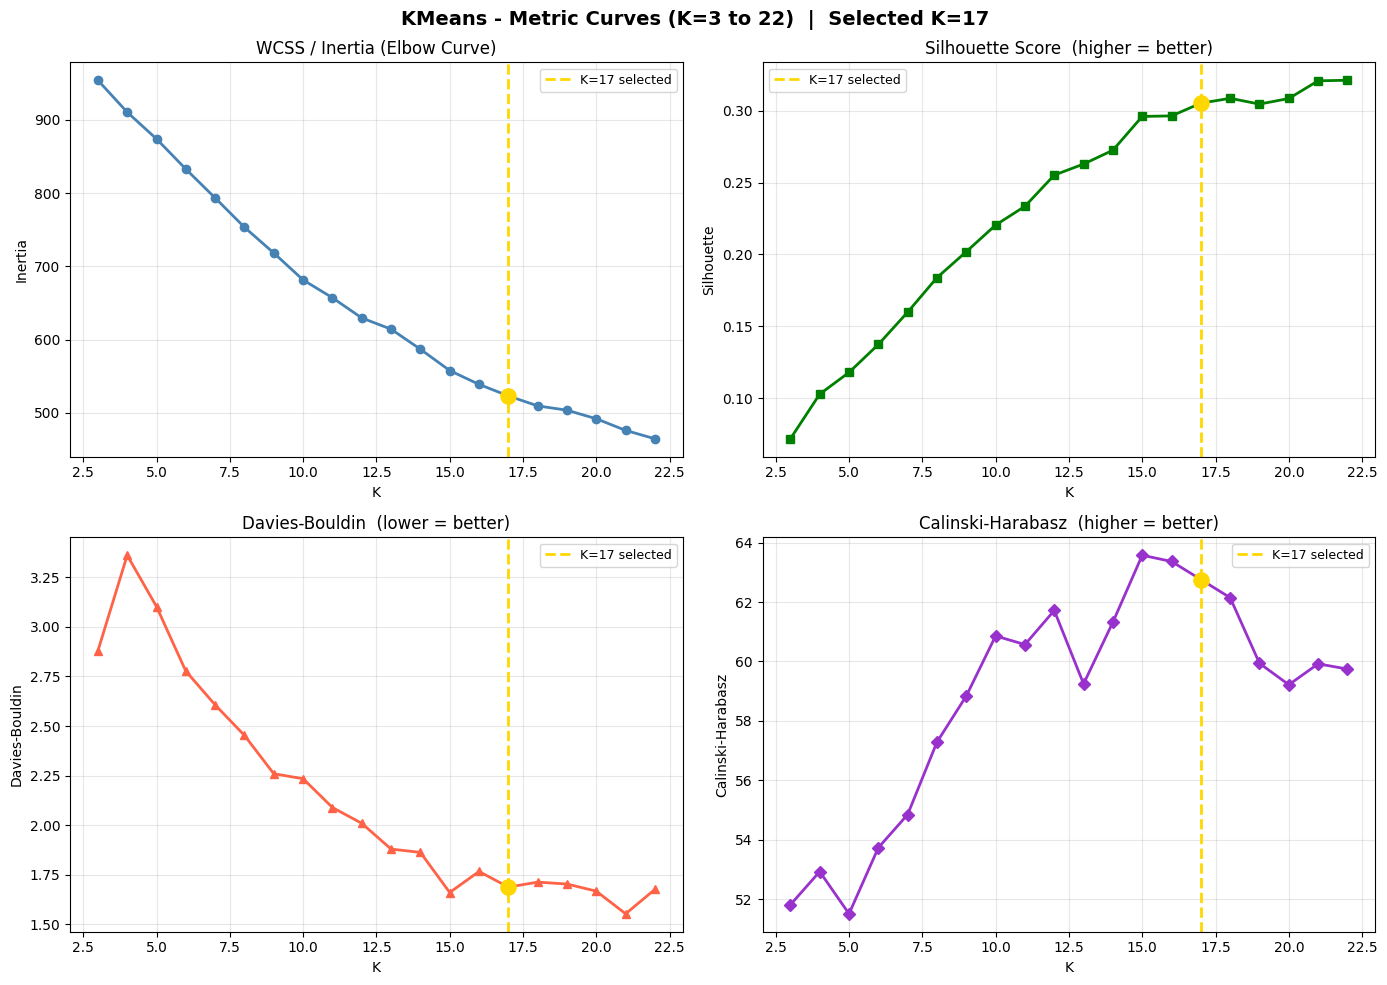

Saved: winner_metric_curves.png


In [10]:
algo_df = plot_df[plot_df['Algorithm'] == BEST_ALGO].sort_values('K')
K_list  = algo_df['K'].tolist()

# Recompute WCSS only for KMeans-family
inertias = []
if BEST_ALGO in ('KMeans', 'MiniBatchKMeans', 'BisectingKMeans'):
    for k in K_list:
        km_tmp = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
        km_tmp.fit(X_final)
        inertias.append(km_tmp.inertia_)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{BEST_ALGO} - Metric Curves (K={K_MIN} to {K_MAX})  |  Selected K={BEST_K}',
             fontsize=14, fontweight='bold')

def mark_best(ax, xs, ys, best_x):
    best_y = ys[xs.index(best_x)]
    ax.axvline(best_x, color='gold', linestyle='--', lw=2, label=f'K={best_x} selected')
    ax.scatter([best_x], [best_y], color='gold', s=120, zorder=5)
    ax.legend(fontsize=9)

# WCSS
ax = axes[0, 0]
if inertias:
    ax.plot(K_list, inertias, marker='o', color='steelblue', lw=2)
    mark_best(ax, K_list, inertias, BEST_K)
    ax.set_title('WCSS / Inertia (Elbow Curve)')
    ax.set_ylabel('Inertia')
else:
    ax.text(0.5, 0.5, f'WCSS not applicable\nfor {BEST_ALGO}',
            transform=ax.transAxes, ha='center', va='center', fontsize=12, color='grey')
    ax.set_title('WCSS (N/A for this algorithm)')
ax.set_xlabel('K'); ax.grid(True, alpha=0.3)

# Silhouette
ax = axes[0, 1]
sil_vals = algo_df['Silhouette'].tolist()
ax.plot(K_list, sil_vals, marker='s', color='green', lw=2)
mark_best(ax, K_list, sil_vals, BEST_K)
ax.set_title('Silhouette Score  (higher = better)')
ax.set_xlabel('K'); ax.set_ylabel('Silhouette'); ax.grid(True, alpha=0.3)

# Davies-Bouldin
ax = axes[1, 0]
db_vals = algo_df['DaviesBouldin'].tolist()
ax.plot(K_list, db_vals, marker='^', color='tomato', lw=2)
mark_best(ax, K_list, db_vals, BEST_K)
ax.set_title('Davies-Bouldin  (lower = better)')
ax.set_xlabel('K'); ax.set_ylabel('Davies-Bouldin'); ax.grid(True, alpha=0.3)

# Calinski-Harabasz
ax = axes[1, 1]
ch_vals = algo_df['CalinskiHarabasz'].tolist()
ax.plot(K_list, ch_vals, marker='D', color='darkorchid', lw=2)
mark_best(ax, K_list, ch_vals, BEST_K)
ax.set_title('Calinski-Harabasz  (higher = better)')
ax.set_xlabel('K'); ax.set_ylabel('Calinski-Harabasz'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('winner_metric_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: winner_metric_curves.png')

## 10. Best-Per-Algorithm Comparison Bars

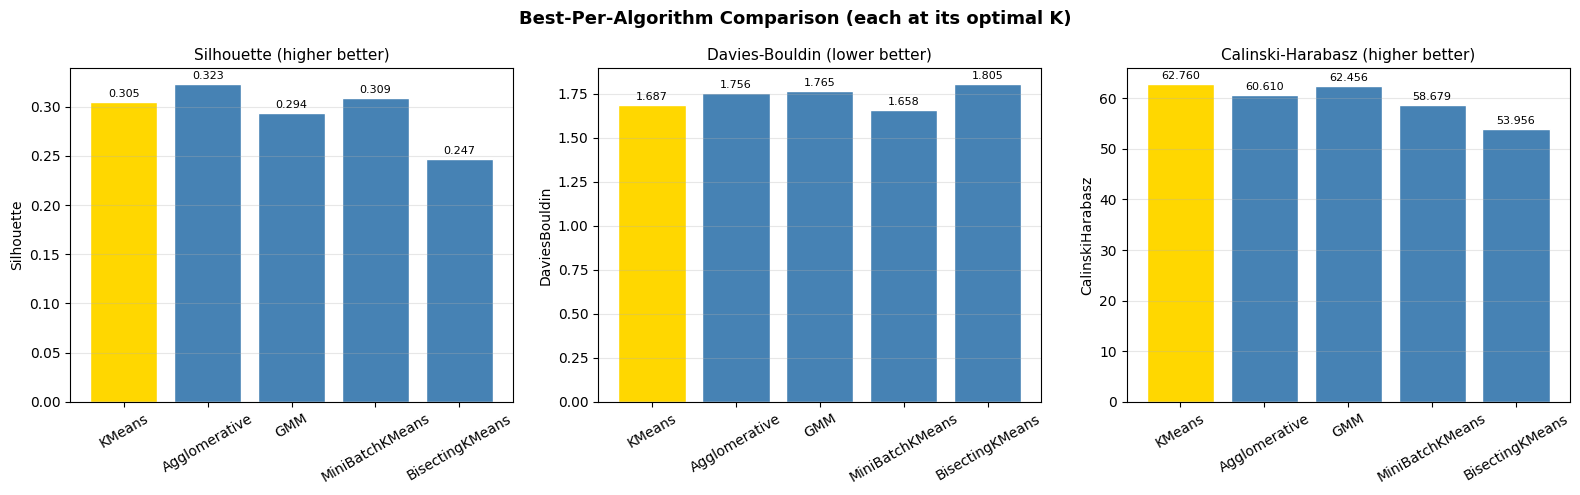

Saved: algo_comparison_bars.png

      Algorithm  K  Silhouette  DaviesBouldin  CalinskiHarabasz  MinClusterSize  CombinedScore
         KMeans 17    0.305198       1.687242         62.760027            22.0       2.877854
  Agglomerative 22    0.322821       1.756046         60.610300            17.0       2.860674
            GMM 16    0.293562       1.765185         62.456237            22.0       2.806790
MiniBatchKMeans 21    0.308868       1.658243         58.679324            20.0       2.786961
BisectingKMeans 16    0.247096       1.805446         53.956071            15.0       2.400300


In [11]:
best_per = plot_df.loc[plot_df.groupby('Algorithm')['CombinedScore'].idxmax()].copy()
best_per = best_per.sort_values('CombinedScore', ascending=False)
colors   = ['gold' if a == BEST_ALGO else 'steelblue' for a in best_per['Algorithm']]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Best-Per-Algorithm Comparison (each at its optimal K)",
             fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes, [
    ('Silhouette',       'Silhouette (higher better)'),
    ('DaviesBouldin',    'Davies-Bouldin (lower better)'),
    ('CalinskiHarabasz', 'Calinski-Harabasz (higher better)'),
]):
    bars = ax.bar(best_per['Algorithm'], best_per[col], color=colors, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(label, fontsize=11); ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=30); ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('algo_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: algo_comparison_bars.png')
print()
print(best_per[['Algorithm','K','Silhouette','DaviesBouldin',
               'CalinskiHarabasz','MinClusterSize','CombinedScore']].to_string(index=False))

## 11. Final Model — Refit Winner with n_init=50

In [12]:
ALGO_FINAL = {
    'KMeans'          : KMeans(n_clusters=BEST_K, n_init=50, random_state=RANDOM_STATE),
    'MiniBatchKMeans' : MiniBatchKMeans(n_clusters=BEST_K, n_init=50,
                                        random_state=RANDOM_STATE, batch_size=256),
    'BisectingKMeans' : BisectingKMeans(n_clusters=BEST_K, random_state=RANDOM_STATE,
                                         bisecting_strategy='largest_cluster'),
    'Agglomerative'   : AgglomerativeClustering(n_clusters=BEST_K, linkage='ward'),
    'GMM'             : GaussianMixture(n_components=BEST_K, n_init=20,
                                        random_state=RANDOM_STATE, covariance_type='diag'),
}

final_model  = ALGO_FINAL[BEST_ALGO]
final_labels = final_model.fit_predict(X_final)
df['Cluster'] = final_labels

sil_f = silhouette_score(X_final[idx_samp], final_labels[idx_samp], random_state=RANDOM_STATE)
db_f  = davies_bouldin_score(X_final[idx_samp], final_labels[idx_samp])
ch_f  = calinski_harabasz_score(X_final[idx_samp], final_labels[idx_samp])

print(f'Final {BEST_ALGO}  K={BEST_K}  n_init=50')
print(f'  Silhouette        = {sil_f:.4f}')
print(f'  Davies-Bouldin    = {db_f:.4f}')
print(f'  Calinski-Harabasz = {ch_f:.2f}')
print()
print('Cluster distribution:')
print(df['Cluster'].value_counts().sort_index())

Final KMeans  K=17  n_init=50
  Silhouette        = 0.3052
  Davies-Bouldin    = 1.6872
  Calinski-Harabasz = 62.76

Cluster distribution:
Cluster
0      22
1      35
2      88
3      80
4      81
5     141
6      55
7      64
8      37
9     117
10     30
11     54
12    134
13     37
14     51
15     70
16     29
Name: count, dtype: int64


## 12. Cluster Profiling and Naming

Each cluster is inspected for its dominant Activity categories and sample descriptions, then given a descriptive name.

In [13]:
print('=== Cluster Composition ===')
for c in sorted(df['Cluster'].unique()):
    sub  = df[df['Cluster'] == c]
    tops = sub['Actvitiy'].value_counts()
    dom  = tops.index[0]; pct = tops.iloc[0] / len(sub) * 100
    print(f'  C{c:2d} (n={len(sub):4d}, dom={dom} {pct:.0f}%)  {dict(tops.head(3))}')
    print(f'       sample: "{sub["Description"].iloc[0][:68]}"')

# ── AUTO-NAME each cluster from its actual dominant activity ─────────────────
# This approach is CORRECT and does NOT use a hardcoded map that breaks when
# KMeans assigns different cluster IDs across runs.
def make_cluster_name(cluster_id, df_full):
    sub  = df_full[df_full['Cluster'] == cluster_id]
    tops = sub['Actvitiy'].value_counts()
    dom  = tops.index[0]
    pct  = tops.iloc[0] / len(sub) * 100
    if pct >= 90:   # cluster is dominated by one activity
        return dom
    elif pct >= 60:
        second = tops.index[1] if len(tops) > 1 else ''
        return f'{dom} / {second}'
    else:           # mixed cluster — list top 2-3
        parts = list(tops.index[:3])
        return ' + '.join(parts)

cluster_names = {c: make_cluster_name(c, df) for c in sorted(df['Cluster'].unique())}
df['Cluster_Name'] = df['Cluster'].map(cluster_names)

print('\n=== Final Cluster Names (auto-generated from dominant activity) ===')
for c, name in cluster_names.items():
    n = (df['Cluster'] == c).sum()
    print(f'  Cluster {c:2d} (n={n:4d}): {name}')


=== Cluster Composition ===
  C 0 (n=  22, dom=Music Playing 100%)  {'Music Playing': 22}
       sample: "Accordion, sitting"
  C 1 (n=  35, dom=Sports 54%)  {'Sports': 19, 'Water Activities': 7, 'Walking': 6}
       sample: "Jog/walk combination (jogging component of less than 10 minutes) (Ta"
  C 2 (n=  88, dom=Conditioning Exercise 99%)  {'Conditioning Exercise': 87, 'Video Games': 1}
       sample: "Aerobic, general"
  C 3 (n=  80, dom=Water Activities 100%)  {'Water Activities': 80}
       sample: "Boating, power, driving"
  C 4 (n=  81, dom=Home Activities 100%)  {'Home Activities': 81}
       sample: "Cleaning, sweeping carpet or floors, general"
  C 5 (n= 141, dom=Occupation 99%)  {'Occupation': 139, 'Sexual Activity': 2}
       sample: "Active workstation, Pedal desk, balance chair/ball, General, light e"
  C 6 (n=  55, dom=Lawn & Garden 100%)  {'Lawn & Garden': 55}
       sample: "Carrying, loading or stacking wood, loading/unloading or carrying lu"
  C 7 (n=  64, dom=Running

## 13. Activity -> Cluster Heatmap

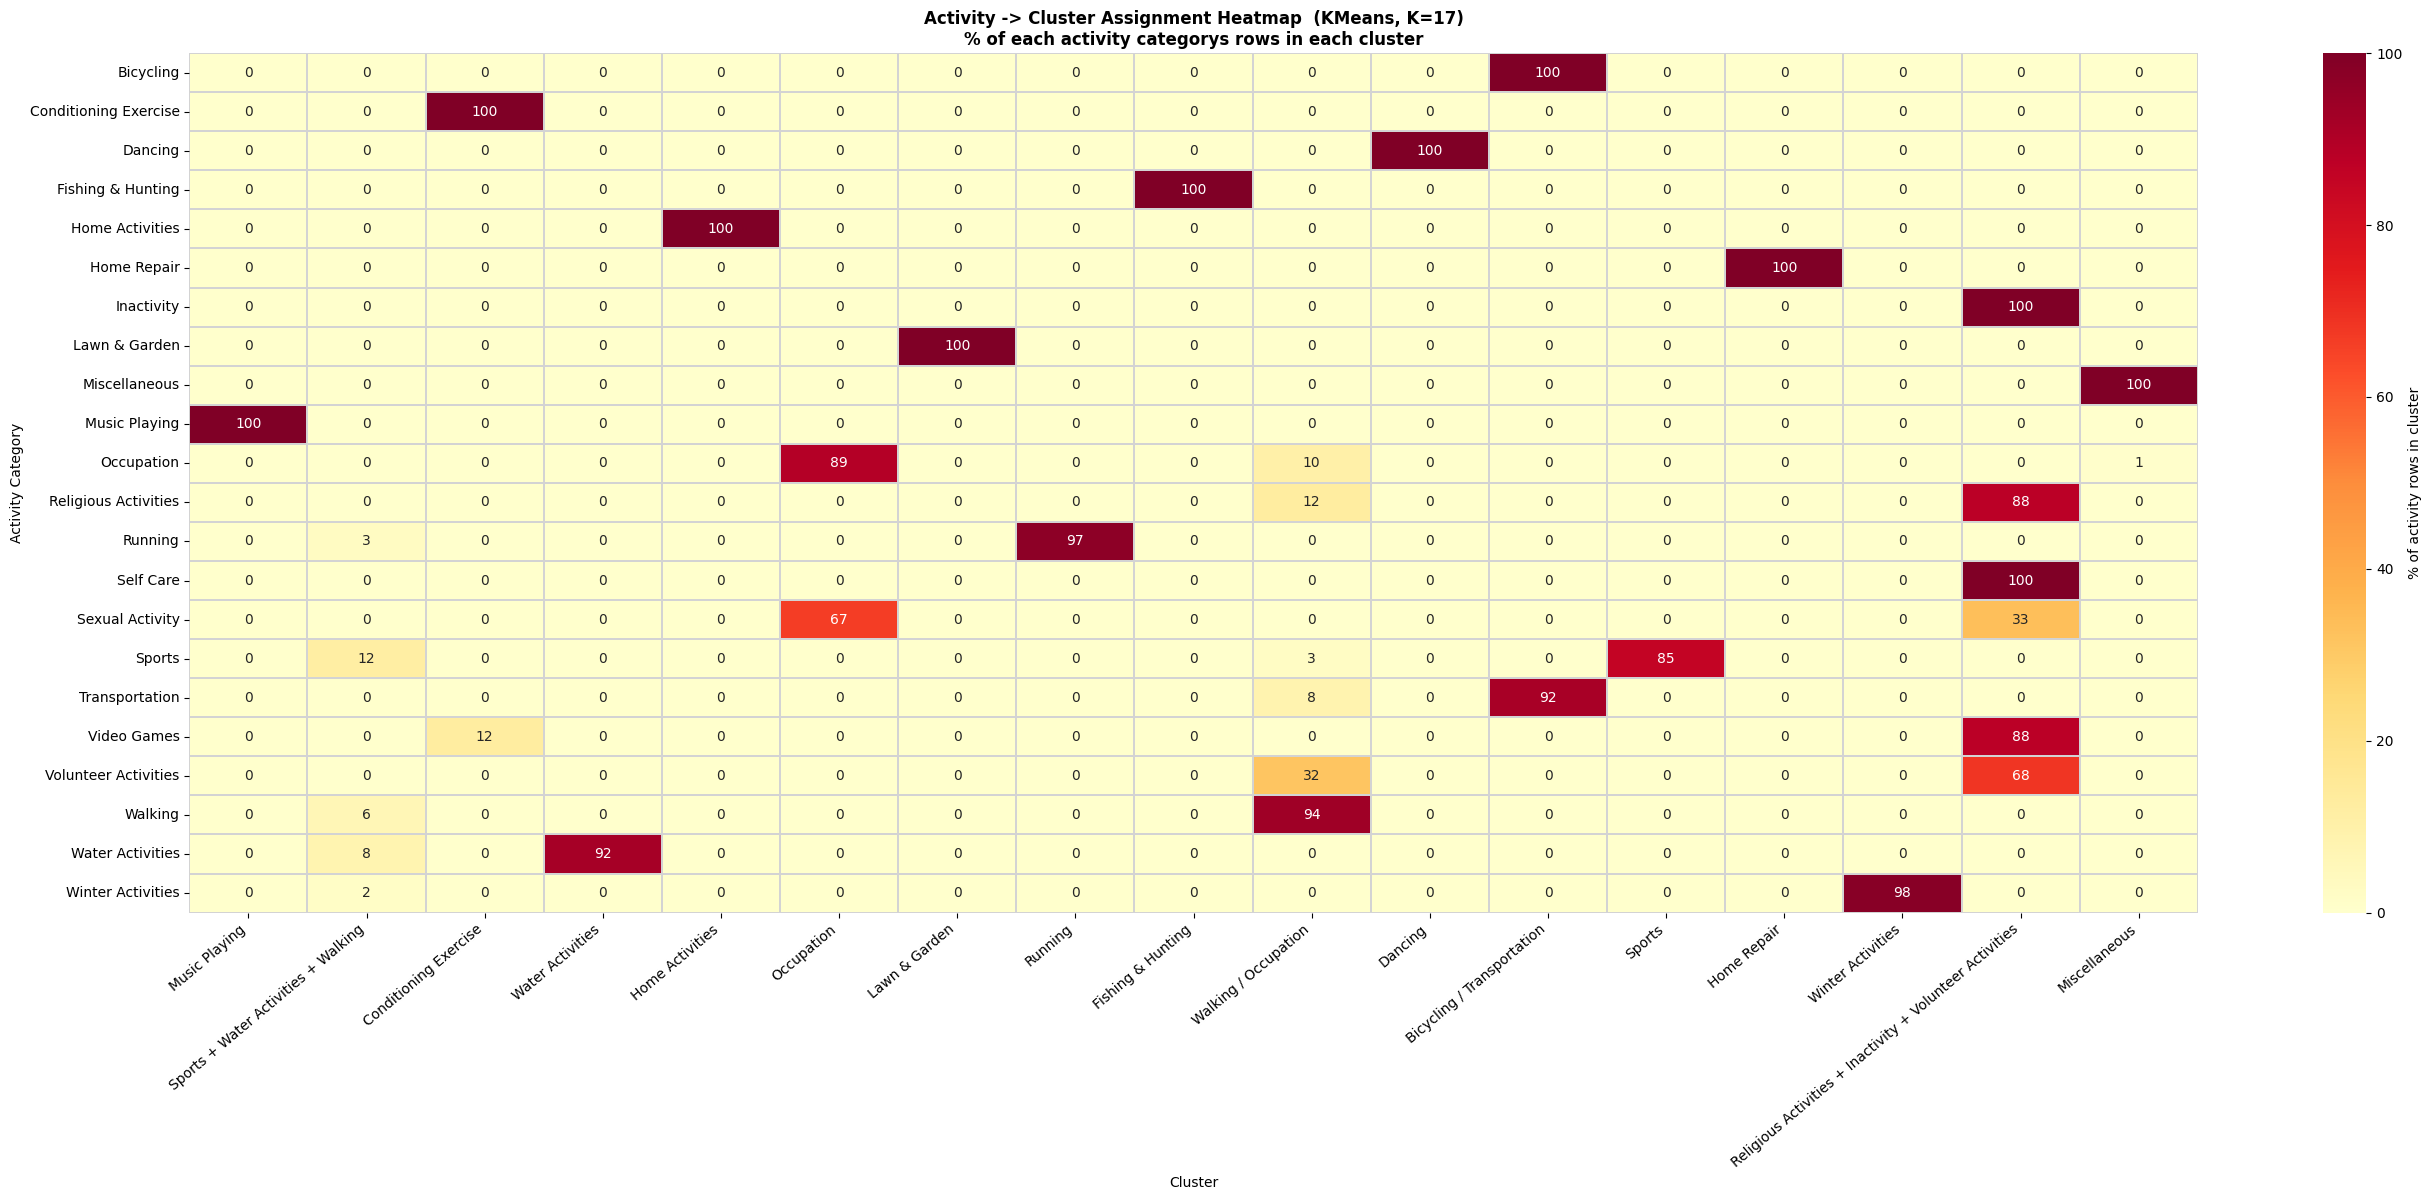

Saved: activity_cluster_heatmap.png


In [14]:
ct     = pd.crosstab(df['Actvitiy'], df['Cluster'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.columns = [cluster_names[c] for c in ct_pct.columns]

fig_h = max(10, len(ct_pct) * 0.55)
fig_w = max(12, BEST_K * 1.6)

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(ct_pct, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.3, linecolor='lightgrey',
            cbar_kws={'label': '% of activity rows in cluster'})
plt.title(
    f'Activity -> Cluster Assignment Heatmap  ({BEST_ALGO}, K={BEST_K})\n'
    '% of each activity categorys rows in each cluster',
    fontsize=12, fontweight='bold')
plt.xlabel('Cluster'); plt.ylabel('Activity Category')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('activity_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: activity_cluster_heatmap.png')

## 14. Cluster Size Bar Chart

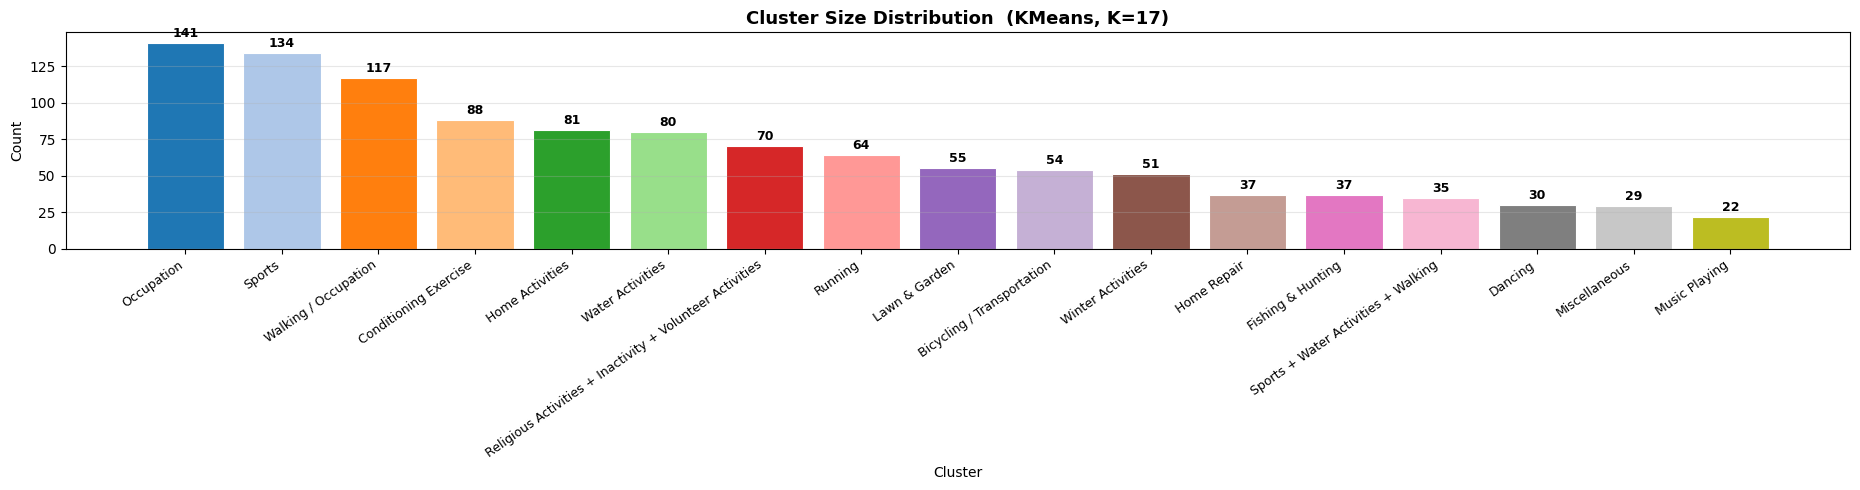

Saved: cluster_sizes.png


In [15]:
sizes   = df.groupby('Cluster_Name').size().sort_values(ascending=False)
palette = sns.color_palette('tab20', n_colors=len(sizes))

fig, ax = plt.subplots(figsize=(max(10, len(sizes)*1.1), 5))
bars = ax.bar(range(len(sizes)), sizes.values, color=palette, edgecolor='white', lw=0.8)
for bar, v in zip(bars, sizes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+2, str(v),
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(sizes)))
ax.set_xticklabels(sizes.index, rotation=35, ha='right', fontsize=9)
ax.set_xlabel('Cluster'); ax.set_ylabel('Count')
ax.set_title(f'Cluster Size Distribution  ({BEST_ALGO}, K={BEST_K})',
             fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cluster_sizes.png')

## 15. 2D Scatter — PCA for visualisation only

2D PCA: PC1=6.4%  PC2=5.5%  Total=11.9%


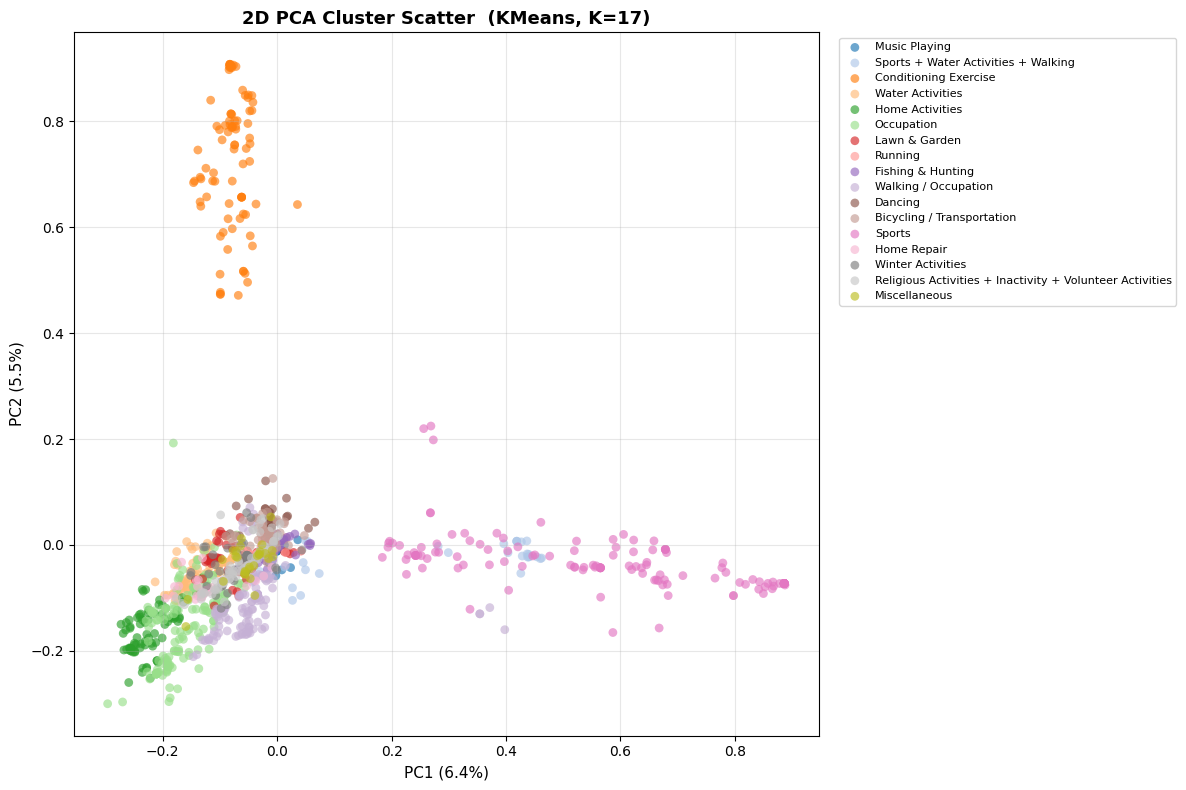

Saved: cluster_scatter_2d.png


In [16]:
pca_2d  = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d    = pca_2d.fit_transform(X_final)
var_exp = pca_2d.explained_variance_ratio_
print(f'2D PCA: PC1={var_exp[0]*100:.1f}%  PC2={var_exp[1]*100:.1f}%  Total={sum(var_exp)*100:.1f}%')

palette_2d = sns.color_palette('tab20', n_colors=BEST_K)
plt.figure(figsize=(12, 8))
for c in sorted(df['Cluster'].unique()):
    mask_c = df['Cluster'].values == c
    plt.scatter(X_2d[mask_c, 0], X_2d[mask_c, 1],
                label=cluster_names[c], color=palette_2d[c],
                alpha=0.65, s=40, edgecolors='none')
plt.title(f'2D PCA Cluster Scatter  ({BEST_ALGO}, K={BEST_K})', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', fontsize=11)
plt.ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_scatter_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cluster_scatter_2d.png')

## 16. 3D Scatter — Plotly saved as HTML
> `fig.show()` intentionally omitted — WebGL not supported in your Jupyter environment. Open the HTML file in Chrome / Edge / Firefox.

In [17]:
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_3d   = pca_3d.fit_transform(X_final)
var3   = pca_3d.explained_variance_ratio_

df_3d = pd.DataFrame({
    'PC1': X_3d[:,0], 'PC2': X_3d[:,1], 'PC3': X_3d[:,2],
    'Cluster'     : df['Cluster'].astype(str),
    'ClusterName' : df['Cluster_Name'],
    'Activity'    : df['Actvitiy'],
    'Description' : df['Description'].str[:80],
})

fig_3d = px.scatter_3d(
    df_3d, x='PC1', y='PC2', z='PC3', color='Cluster',
    hover_name='Activity',
    hover_data={'ClusterName':True,'Description':True,
                'PC1':':.3f','PC2':':.3f','PC3':':.3f'},
    title=(f'3D PCA Cluster Scatter - {BEST_ALGO}  K={BEST_K}<br>'
           f'PC1={var3[0]*100:.1f}% | PC2={var3[1]*100:.1f}% | PC3={var3[2]*100:.1f}%'),
    color_discrete_sequence=px.colors.qualitative.Plotly,
    template='plotly_white', opacity=0.75
)
fig_3d.update_traces(marker=dict(size=4))
fig_3d.update_layout(
    scene=dict(
        xaxis_title=f'PC1 ({var3[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({var3[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({var3[2]*100:.1f}%)'),
    legend_title='Cluster', margin=dict(l=0,r=0,b=0,t=80))

html_path = 'cluster_3d_scatter.html'
fig_3d.write_html(html_path, include_plotlyjs='cdn')
print(f'3D scatter saved -> {html_path}')
print('Open in Chrome / Edge / Firefox to explore interactively.')

3D scatter saved -> cluster_3d_scatter.html
Open in Chrome / Edge / Firefox to explore interactively.


## 17. Export — All Artefacts

In [18]:
df[['Actvitiy','Description','Cluster','Cluster_Name']].to_csv(
    'physical_activity_clustered.csv', index=False)
print('physical_activity_clustered.csv saved')

with open('final_model.pkl', 'wb') as f:       pickle.dump(final_model, f)
with open('tfidf_vectorizer.pkl', 'wb') as f:  pickle.dump(tfidf, f)
with open('svd_model.pkl', 'wb') as f:         pickle.dump(svd, f)
print('final_model.pkl  tfidf_vectorizer.pkl  svd_model.pkl  saved')

race_df.to_csv('algorithm_race_results.csv', index=False)
pd.DataFrame(list(cluster_names.items()), columns=['Cluster','Name']).to_csv(
    'cluster_names.csv', index=False)
print('algorithm_race_results.csv  cluster_names.csv  saved')

print('\nAll outputs:')
outputs = [
    'physical_activity_clustered.csv', 'final_model.pkl',
    'tfidf_vectorizer.pkl', 'svd_model.pkl',
    'algorithm_race_results.csv', 'cluster_names.csv',
    'cluster_3d_scatter.html',
    'svd_variance.png', 'dbscan_kdist.png',
    'algo_metric_heatmaps.png', 'combined_score_heatmap.png',
    'winner_metric_curves.png', 'algo_comparison_bars.png',
    'activity_cluster_heatmap.png', 'cluster_sizes.png',
    'cluster_scatter_2d.png',
]
for o in outputs: print(f'  {o}')

physical_activity_clustered.csv saved
final_model.pkl  tfidf_vectorizer.pkl  svd_model.pkl  saved
algorithm_race_results.csv  cluster_names.csv  saved

All outputs:
  physical_activity_clustered.csv
  final_model.pkl
  tfidf_vectorizer.pkl
  svd_model.pkl
  algorithm_race_results.csv
  cluster_names.csv
  cluster_3d_scatter.html
  svd_variance.png
  dbscan_kdist.png
  algo_metric_heatmaps.png
  combined_score_heatmap.png
  winner_metric_curves.png
  algo_comparison_bars.png
  activity_cluster_heatmap.png
  cluster_sizes.png
  cluster_scatter_2d.png


## 18. Reload Pipeline and Predict New Data

In [19]:
with open('tfidf_vectorizer.pkl','rb') as f: _tfidf = pickle.load(f)
with open('svd_model.pkl',       'rb') as f: _svd   = pickle.load(f)
with open('final_model.pkl',     'rb') as f: _model = pickle.load(f)

def predict_cluster(activity: str, description: str) -> dict:
    """Predict cluster for a new activity + description pair."""
    text   = activity.lower().replace('&','and') + ' ' + description.lower()
    X_tf   = _tfidf.transform([text])
    X_s    = _svd.transform(X_tf)
    X_n    = normalize(X_s, norm='l2')
    c      = int(_model.predict(X_n)[0])
    return {'cluster_id': c, 'cluster_name': cluster_names[c]}

test_cases = [
    ('Running',         'jogging outdoors, moderate pace, flat terrain'),
    ('Sports',          'basketball, half-court game, recreational'),
    ('Occupation',      'computer work, typing at desk, sitting'),
    ('Bicycling',       'mountain biking, downhill, vigorous effort'),
    ('Home Activities', 'vacuuming carpets, general housework'),
]
print('Prediction examples:')
for act, desc in test_cases:
    r = predict_cluster(act, desc)
    print(f'  [{act}] {desc[:48]}')
    print(f'    -> Cluster {r["cluster_id"]}: {r["cluster_name"]}')

Prediction examples:
  [Running] jogging outdoors, moderate pace, flat terrain
    -> Cluster 7: Running
  [Sports] basketball, half-court game, recreational
    -> Cluster 12: Sports
  [Occupation] computer work, typing at desk, sitting
    -> Cluster 5: Occupation
  [Bicycling] mountain biking, downhill, vigorous effort
    -> Cluster 11: Bicycling / Transportation
  [Home Activities] vacuuming carpets, general housework
    -> Cluster 4: Home Activities
